# Axes Components

Now that we can create figures and axes, let's explore what's actually inside an Axes object. Every Axes contains several key components:
- **Spines**: The four borders (top, bottom, left, right)
- **XAxis and YAxis**: Manage ticks, labels, and formatting
- **Tick marks and labels**: The marks and text on axes
- **Axis labels**: xlabel and ylabel
- **Title**: The axes title
- **Legend**: Labels for plot elements
- **Grid**: Optional background grid

Understanding these components gives you complete control over your plot's appearance.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

## *Spines*

*Spines* are the lines that form the rectangular border of the axes. They are the actual lines used to generate the x-axis and the y-axis. There are four spines: 'left', 'right', 'top', 'bottom'.

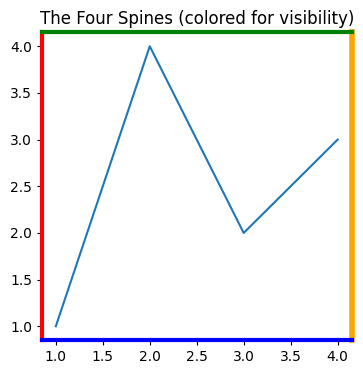

In [12]:
# Create a simple plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])

# Highlight each spine with different colors
ax.spines['left'].set_color('red')
ax.spines['left'].set_linewidth(3)

ax.spines['bottom'].set_color('blue')
ax.spines['bottom'].set_linewidth(3)

ax.spines['top'].set_color('green')
ax.spines['top'].set_linewidth(3)

# right orange
ax.spines['right'].set_color('orange')
ax.spines['right'].set_linewidth(4)
ax.set_title('The Four Spines (colored for visibility)', fontsize=12)
plt.show()

**Each spine:**
- Is a `matplotlib.spines.Spine` object. Represents one edge of the axes rectangle
- Can be independently styled (color, width, style):   
  - `set_color(color)`. Set spine color. Default: black 
  - `set_edgecolor(color)`. Alias for `set_color()` . Default: black
  - `set_linewidth(float)` or `set_lw(float)`. Set spine thickness. Default: 0.8 (or from rcParams)
  - `set_linestyle(style)` or `set_ls(style)`. Set spine line style. Default: 'solid' or '-'
  - `set_capstyle(style)`. Set line cap style for dashed lines. Default: 'projecting'. Values: 'butt', 'projecting', 'round'
- Can be shown/hidden:
  - `set_visible(bool)`. Show or hide the spine. Default: True
  - `set_alpha(float)`. Set spine transparency. Default: 1.0. (0 = fully transparent, 1 = opaque)
- Can be positioned anywhere (not just at edges):
  - `set_position(position)`. Set spine position. Default: ('outward', 0)
      - ('outward', points) - offset in points, e.g., ('outward', 10)
      - ('axes', fraction) - position in axes coords, e.g., ('axes', 0.5)
      - ('data', value) - position at data coordinate, e.g., ('data', 0)
'     - center' - shorthand for ('axes', 0.5)
      - 'zero' - shorthand for ('data', 0.0)
  - `set_bounds(low, high)`. Set spine extent along its axis. Default: Full axis range. Values: (min_value, max_value) in data coordinates, e.g., set_bounds(0, 10)

In [13]:
fig, ax = plt.subplots(figsize=(4,4))

# Basic plot for context
ax.plot([0, 1, 2, 3], [1, 3, 2, 4], marker='o')

# set_position(): move the left spine inward
    # 'axes', 0.2
# ('axes', value) means "20% of the axes width from the left"

# set_bounds(): limit the visible portion of the spine
    # left 1,3
    # bottom 1, 2.5


# set_visible(): get rid off some spines
    ax.spines['right'].set_visible(False)# right 
    # top 

# Add minimal labeling
ax.set_title("Spine: position, bounds, and capstyle", size= 12)
ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.show()

IndentationError: unexpected indent (1281931843.py, line 16)

```{caution}
In Polar coordinate plots, the standard Cartesian spine names are mapped to polar-specific names:   

- 'polar' instead of 'top' (outer circular/arc spine)
- 'inner' instead of (inner circular/arc spine)
- 'start' instead of (radial line at starting angle)
- 'end' instead of (radial line at ending angle)
```

## *XAxis* and *YAxis*

Each Axes contains two Axis objects that manage the x and y axes.

**Important terminology:**
- **Axes** (plural, `ax`): The entire plotting area
- **Axis** (singular, `ax.xaxis` or `ax.yaxis`): A single dimension (x or y)

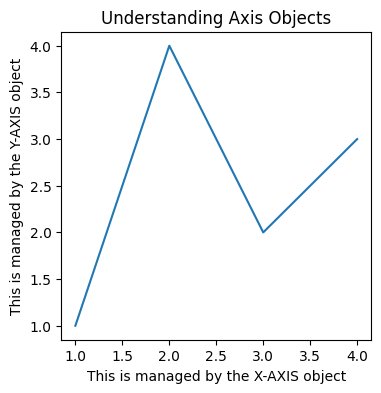

In [14]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])

ax.set_title('Understanding Axis Objects', fontsize=12)
ax.set_xlabel('This is managed by the X-AXIS object')
ax.set_ylabel('This is managed by the Y-AXIS object')

plt.show()

Each **Axis** object:
- Manages tick positions (major and minor)
- Manages tick labels
- Contains tick locators (determine where ticks go)
- Contains tick formatters (determine how tick labels look)
- Handles the axis label
- Controls the scale (linear, log, etc.)

### *Tick Marks and Labels*

Ticks are the small marks on the axes with corresponding labels.

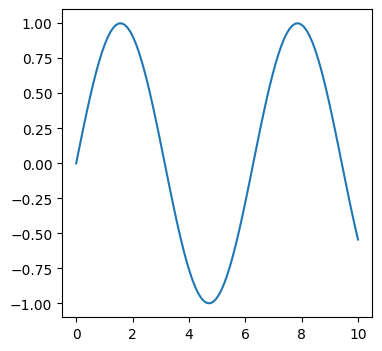

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))

# Create data
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x))

plt.show()

In [16]:
# Get current tick positions 


In [17]:
# Get tick labels (text object)


In [18]:
# Extract the actual text
labels = [label.get_text() for label in xticklabels]
labels

NameError: name 'xticklabels' is not defined

```{note}
Notice that matplotlib's tick locators generate "nice" evenly-spaced values that may extend beyond the visible axis range, but only ticks **within the limits** are actually displayed.
```

### Major vs Minor Tick Marks

Ticks can actually be of different types:   

**Major ticks**
- The primary ticks used for labeling the axis.
- Usually fewer in number.
- Carry tick labels (numbers or text).
- Controlled by the major locator and major formatter.

**Minor ticks**
- Additional ticks between major ticks.
- Usually no labels by default.
- Useful for precision, grid alignment, or visual guidance.
- You enable minor ticks with:
  - `ax.minorticks_on()`
  - `ax.minorticks_off()`

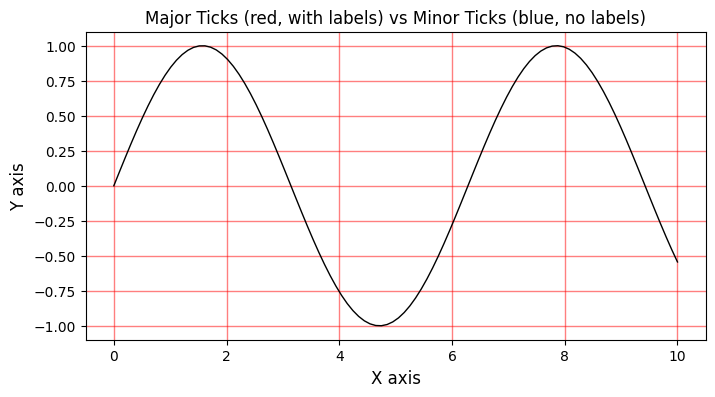

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))

# Create data
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), linewidth=1, color='black', zorder= 10)

# Enable minor ticks


# Customize major ticks


# Customize minor ticks


ax.set_xlabel('X axis', fontsize=12)
ax.set_ylabel('Y axis', fontsize=12)
ax.set_title('Major Ticks (red, with labels) vs Minor Ticks (blue, no labels)', fontsize=12)

# Customize grid
ax.grid(True, which='major', alpha=0.5, linestyle='-', linewidth=1, color='red')
ax.grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=1, color= 'blue')

plt.show()

#### Getting/Setting Tick Positions and Labels

Matplolib offers different ways of customizing the location and the format of the tick labels You can manually set where ticks appear. You can do this by setting the xticks, yticks, xticklabels and yticklabels directly using:
- `ax.get_xticks()` / `ax.set_xticks()`
- `ax.get_yticks()` /`ax.set_yticks()`
- `ax.get_xticklabels()` / `ax.set_xticklabels()`
- `ax.get_yticklabels()` / `ax.set_yticklabels()`

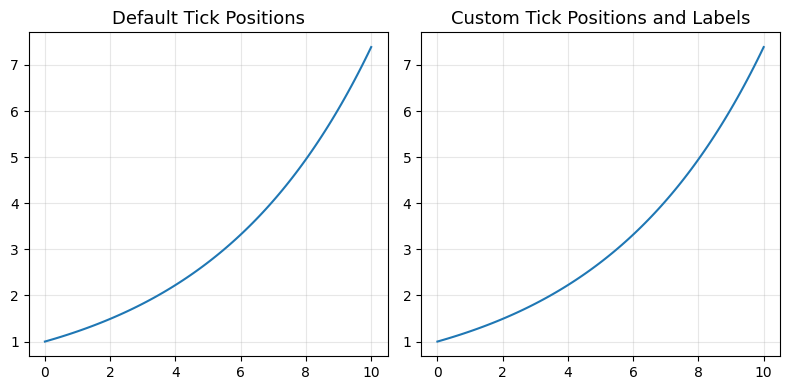

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

# Create data
x = np.linspace(0, 10, 100)

# Default ticks
axs[0].plot(x, np.exp(x/5))
axs[0].set_title('Default Tick Positions', fontsize=13)
axs[0].grid(True, alpha=0.3)

# Custom ticks
axs[1].plot(x, np.exp(x/5))
    # Custom x positions
    # Custom y positions
    # Custom xtick labels
    # Custom ytick labels

axs[1].set_title('Custom Tick Positions and Labels', fontsize=13)
axs[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

#### Tick Labels Styling

Tick label properties can be set using `ax.set_xticklabels()` / `ax.set_yticklabels()` 

**Main Parameters:**

- `labels` - The label strings (required). e.g., ax.set_xticklabels(['A', 'B', 'C'])   
- `fontsize` or `size` - Font size. Default: From rcParams Values: Float or 'small', 'medium', 'large', 'x-large', etc. e.g., fontsize=12 or size='large'
- `rotation` - Rotation angle in degrees. Default: 0. Values: Float (degrees) or 'vertical', 'horizontal' e.g., rotation=45
- `ha` / `horizontalalignment` - Horizontal alignment. Default: Depends on rotation. Values: 'left', 'center', 'right'. e.g., ha='right'
- `va` / `verticalalignment` - Vertical alignment. Default: Depends on position. Values: 'top', 'center', 'bottom', 'baseline'
e.g., va='top'
- `color` - Label text color. Default: 'black'. Values: Any matplotlib color. e.g., color='red'
- `weight` / `fontweight` - Font weight. Default: 'normal'. Values: 'normal', 'bold', 'light', 'heavy', or numeric (100-900). e.g., weight='bold'
- `family` / `fontfamily` - Font family. Default: From rcParams Values: 'serif', 'sans-serif', 'monospace', or specific font name. e.g. family='monospace'
-`style` / `fontstyle` - Font style. Default: 'normal'. Values: 'normal', 'italic', 'oblique'. e.g., style='italic'
- `minor` - Apply to minor ticks instead of major. Default: False. Values: True, False. e.g., `ax.set_xticklabels(labels, minor=True)`

#### tick_params()

In addition to the above, Matplotlib also allows to style ticks and tick labels via `ax.tick_params()`function. This function is convenient when you want to do a lot of changes at the same time, instead of having to call individually functions.

**`tick_params()` Main Parameters:**
- `axis`. which axis. Default: 'x'. Values: 'x', 'y', 'both'
- `which`. which tick marks. Default: 'major'. Values: 'major', 'minor', 'both'   

*Tick line appearance*   
- `length`. length of tick marks in points. Default: varies. Values: any positive number
- `width`. line width of tick marks. Default: varies. Values: any positive number
- `color`. color of tick marks. Default: `'black'`. Values: any valid Matplotlib color
- `direction`. direction tick marks point. Default: `'out'`. Values: `'in'`, `'out'`, `'inout'`
- `pad`. distance between tick and label in points. Default: varies. Values: any non‑negative number   

*Tick label appearance*   
- `labelsize`. size of tick label text. Default: varies. Values: any positive number or size string
- `labelcolor`. color of tick label text. Default: `'black'`. Values: any valid Matplotlib color
- `rotation`. rotation angle of tick labels. Default: `0`. Values: any number (degrees)    

*Enabling/disabling*
- `bottom`, `top`, `left`, `right`. control visibility of tick marks on each side. Default: depends on axis. Values: `True`, `False`
- `labelbottom`, `labeltop`, `labelleft`, `labelright`. control visibility of tick labels on each side. Default: depends on axis. Values: `True`, `False`


#### Tick Locators and Formatters

Matplotlib defines an object called a `ticker` that can be used to create a wide variety of ticks marks and label types.
``` python
import matplotlib.ticker as ticker
```

Through the `ticker` object we can access:
- *Locators* - Determine WHERE ticks are placed on the axis
- *Formatters* - Determine HOW tick labels are displayed

Matplotlib creates a version of both of these by default. You can get access to these using the following
- `ax.xaxis.get_major_locator()` / `ax.xaxis.get_minor_locator()`,  same for y
- `ax.xaxis.get_major_formatter()` / `ax.xaxis.get_minor_formatter()`, same for y

Equally, you can set them using the following,
- `ax.xaxis.set_major_locator()` / `ax.xaxis.get_minor_locator()`,  same for y
- `ax.xaxis.set_major_formatter()` / `ax.xaxis.get_minor_formatter()`, same for y

#### *Locators*

There are several different types of ticker locators. Each may have its own parameters:

- `AutoLocator`: Automatically choose nice tick locations (default)
- `NullLocator`: No ticks
- `MultipleLocator(n)`: Ticks at multiples of n
- `MaxNLocator(nbins)`: At most nbins+1 ticks
- `LinearLocator(numticks)`: Exactly numticks evenly spaced
- `LogLocator()`: For logarithmic scales
- `FixedLocator(locs)`: Ticks at exact locations provided

In [21]:
import matplotlib.ticker as ticker

In [22]:
titles = ['AutoLocator', 'NullLocator',  'MultipleLocator(n)', 'MaxNLocator(nbins)',  'LinearLocator(numticks)', 'LogLocator()', 'FixedLocator(locs)']
fig, axs = plt.subplots(2, 4, figsize= (16,8))

axs= axs.ravel()
for ax, title in zip (axs, titles):
    ax.plot([1, 2, 3, 5], [1, 4, 2, 3])
    ax.set_title(title, size= 10)
axs[0].xaxis.set_major_locator(ticker.AutoLocator())
axs[1].xaxis.set_major_locator(ticker.NullLocator())
axs[2].xaxis.set_major_locator(ticker.)  # Major MultipleLocator every 2.0 
axs[2].xaxis.set_minor_locator(ticker.)  # Minor MultipleLocator every 0.25
axs[3].xaxis.set_major_locator(ticker.)  # MaxNLocator Max 7 ticks
axs[4].xaxis.set_major_locator(ticker.)  # LinearLocator 7
axs[5].xaxis.set_major_locator(ticker.)  # LogLocator base 2
axs[6].xaxis.set_major_locator(ticker.)
axs[7].axis('off')

plt.show()

SyntaxError: invalid syntax (2819068510.py, line 10)

#### *Formatters*

Similarly, it is possible to have different types of ticker formatters. Each with its own parameters

- `ScalarFormatter()`: Standard numerical formatting (default)
- `NullFormatter()`: No Labels
- `PercentFormatter(xmax)`: Display as percentages
- `StrMethodFormatter(fmt)`: Format using format strings
- `FormatStrFormatter(fmt)`: Printf-style formatting
- `FuncFormatter(func)`: Custom formatting function
- `LogFormatterMathtex()`: For logarithmic scales

In [23]:
titles = ['ScalarFormatter', 'NullFormatter',  'PercentFormatter(xmax)','StrMethodFormatter(fmt)',
          'FormatStrFormatter(fmt)', 'FuncFormatter(func)', 'LogFormatter']
fig, axs = plt.subplots(2,4, figsize= (16,8))

axs= axs.ravel()
for ax, title in zip (axs, titles):
    ax.plot([1, 2, 3, 5], [1, 4, 2, 3])
    ax.set_title(title, size= 10)
axs[0].xaxis.set_major_formatter(ticker.ScalarFormatter())
axs[1].xaxis.set_major_formatter(ticker.NullFormatter())
axs[2].xaxis.set_major_locator(ticker.FixedLocator([1, 2, 3, 4, 5]))
axs[2].xaxis.set_major_formatter(ticker.)  # FixedFormatter
axs[3].xaxis.set_major_formatter(ticker.)  # PercentFormatter xmax=5 means 5.0 = 100%
axs[4].yaxis.set_major_formatter(ticker.)  # FormatStrFormatter 3 Decimals
axs[5].xaxis.set_major_formatter(ticker.)  # FuncFormatter
axs[6].xaxis.set_major_formatter(ticker.)  # LogFormatterMathtext
axs[7].axis('off')

plt.show()

SyntaxError: invalid syntax (2299010552.py, line 12)

In [38]:
def custom_format(x, pos):
    return f'${x:.0f}K'

#### Axis Labels

Axis labels are set using `set_xlabel()` and `set_ylabel()`.

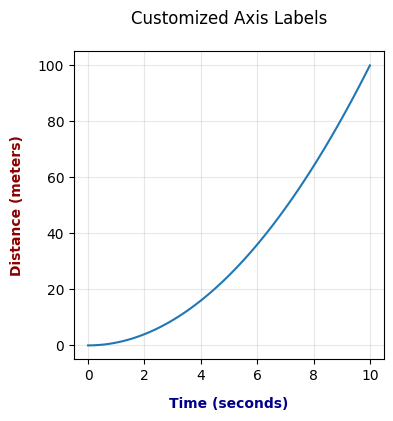

In [41]:
fig, ax = plt.subplots(figsize=(4, 4))

x = np.linspace(0, 10, 100)
ax.plot(x, x**2)

# Set labels with various properties
ax.set_xlabel('Time (seconds)', 
              fontsize=10, 
              fontweight='bold',
              color='darkblue',
              labelpad=10)  # Space between label and axis

ax.set_ylabel('Distance (meters)', 
              fontsize=10,
              fontweight='bold', 
              color='darkred',
              rotation=90,
              labelpad=10)

ax.set_title('Customized Axis Labels', fontsize=12, pad=20)
ax.grid(True, alpha=0.3)

plt.show()

**Label Main parameters:**
- `fontsize`: Size of text
- `fontweight`: 'normal', 'bold', 'heavy', etc.
- `color`: Text color
- `labelpad`: Space between label and axis (in points)
- `rotation`: Angle in degrees (for ylabel)
- `fontstyle`: 'normal', 'italic', 'oblique'

### Scales

The scale of an axes specifies how data values are mapped to visual space, allowing you to choose between representations such as linear, logarithmic, symlog, or logit so the axis reflects the structure of the underlying data.

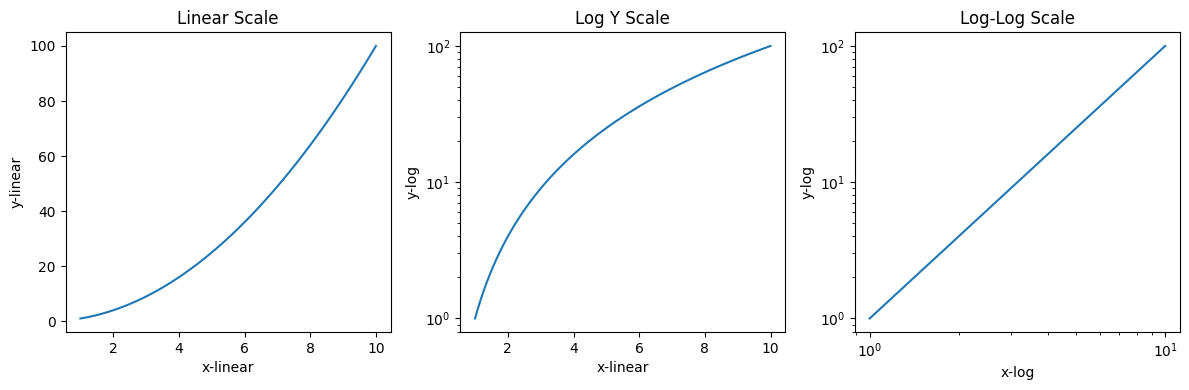

In [23]:
fig, axs = plt.subplots(1,3,figsize=(12, 4))

# Create data
x = np.linspace(1, 10, 100)
y = x**2

# --- Linear scale (Default) ---
axs[0].plot(x, y)
axs[0].set_title("Linear Scale")
axs[0].set_xlabel("x-linear")
axs[0].set_ylabel("y-linear")

# --- Logarithmic y-scale ---
axs[1].plot(x, y)
    # set x log
axs[1].set_title("Log Y Scale")
axs[1].set_xlabel("x-linear")
axs[1].set_ylabel("y-log")

# --- Log-log scale ---
axs[2].plot(x, y)
    # set x log
    # set y log
axs[2].set_title("Log-Log Scale")
axs[2].set_xlabel("x-log")
axs[2].set_ylabel("y-log")

fig.tight_layout()
plt.show()


## *Titles*

Every axes can have a title. There's also a figure-level title (suptitle).

**Title methods:**
- `ax.set_title()`: Title for individual axes
- `fig.suptitle()`: Title for entire figure

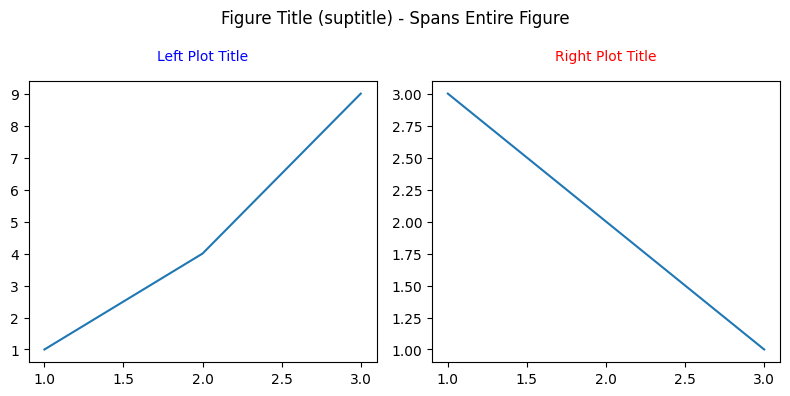

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Axes-level titles
axes[0].plot([1, 2, 3], [1, 4, 9])
axes[0].set_title('Left Plot Title', 
                  fontsize=10, 
                  fontweight='normal', 
                  pad=15,
                  color='blue')

axes[1].plot([1, 2, 3], [3, 2, 1])
axes[1].set_title('Right Plot Title', 
                  fontsize=10, 
                  fontweight='normal', 
                  pad=15,
                  color='red')

# Figure-level title (suptitle)
fig.suptitle('Figure Title (suptitle) - Spans Entire Figure', 
             fontsize=12, 
             fontweight='normal', 
             y=0.98, va= 'top')

fig.tight_layout()
plt.show()

**`set_title()` Main Parameters**

- `label`. the title text. Default: `''`. Values: any string  
- `fontdict`. dictionary of font properties. Default: `None`. Values: any valid font property dict  
- `loc`. title alignment. Default: `'center'`. Values: `'left'`, `'center'`, `'right'`  
- `pad`. distance between title and axes in points. Default: `None` (uses rcParams). Values: any non‑negative number  
- `y`. vertical position of the title in axes coordinates. Default: `None` (uses rcParams). Values: any float (typically between `0` and `1`)  
- `color`. color of the title text. Default: `None` (uses rcParams). Values: any valid Matplotlib color  
- `fontsize`. size of the title text. Default: `None` (uses rcParams). Values: any positive number or size string  
- `fontweight`. weight of the title text. Default: `None` (uses rcParams). Values: `'normal'`, `'bold'`, `'heavy'`, `'light'`, etc.  
- `fontstyle`. style of the title text. Default: `None` (uses rcParams). Values: `'normal'`, `'italic'`, `'oblique'`  
- `family`. font family. Default: `None` (uses rcParams). Values: `'serif'`, `'sans-serif'`, `'monospace'`, etc.  
- `backgroundcolor`. background color behind the title. Default: `None`. Values: any valid Matplotlib color  
- `rotation`. rotation angle of the title. Default: `None` (uses rcParams). Values: any number (degrees)  
- `wrap`. whether to wrap long text. Default: `False`. Values: `True`, `False`  

There are some differences with regards to `.set_suptitle()`:

- `y`. vertical position.  
  - **`set_title()`**: `y` is in **axes coordinates** (`0–1`).  
  - **`set_suptitle()`**: `y` is in **figure coordinates**, typically above `1.0`.

- `x`. horizontal position.  
  - **`set_title()`**: no `x` parameter (title is positioned via `loc`).  
  - **`set_suptitle()`**: has an `x` parameter. Default: `0.5`. Values: any float in figure coordinates.

- `t`. text argument name.  
  - **`set_title()`**: parameter is `label`.  
  - **`set_suptitle()`**: parameter is `t`.
- `pad`.  
  - **`set_title()`**: distance from axes in points.  
  - **`set_suptitle()`**: distance from top of figure in points.
- **Does not** support `loc`.
- **Does not** support `wrap`.
- **Does not** support `backgroundcolor`.


## *Legend*

Adds a legend identifying the different data series in your plot.

```{note}
For a data series to be included in a legend, it must be specified using the ```label=``` parameter.
```

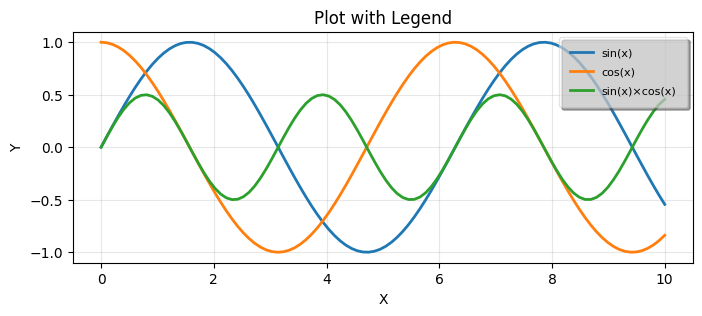

In [24]:
fig, ax = plt.subplots(figsize=(8, 3))

# Create data
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), label='sin(x)', linewidth=2)
ax.plot(x, np.cos(x), label='cos(x)', linewidth=2)
ax.plot(x, np.sin(x) * np.cos(x), label='sin(x)×cos(x)', linewidth=2)

# Create legend
legend = ax.legend(
    loc='upper right',     # Position
    fontsize=8,            # Text size
    framealpha= ,        # Background transparency
    shadow= ,           # Drop shadow
    borderpad=1,           # Padding inside legend
    labelspacing=0.8       # Space between entries
)

ax.set_xlabel('X', fontsize=10)
ax.set_ylabel('Y', fontsize=10)
ax.set_title('Plot with Legend', fontsize=12)
ax.grid(True, alpha=0.3)

plt.show()

**`legend()` Main Parameters:**

- `handles`. the artists to include in the legend. Default: `None`. Values: list of Artist objects or `None`  
- `labels`. text labels for the legend entries. Default: `None`. Values: list of strings or `None`  
- `loc`. location of the legend. Default: `'best'`. Values: `'best'(0)`, `'upper right(1)'`, `'upper left(2)'`, `'lower left(3)'`, `'lower right(4)'`, `'right(5)'`, `'center left(6)'`, `'center right(7)'`, `'lower center(8)'`, `'upper center(9)'`, `'center(10)'`  
- `bbox_to_anchor`. anchor point for the legend box. Default: `None`. Values: tuple of floats or `BboxBase`  
- `ncol`. number of columns in the legend. Default: `1`. Values: any positive integer  
- `prop`. font properties for the legend text. Default: `None`. Values: dict or `FontProperties`  
- `fontsize`. size of legend text. Default: `None`. Values: any positive number or size string  
- `frameon`. whether to draw the legend frame. Default: `True`. Values: `True`, `False`  
- `shadow`. whether to draw a shadow behind the legend. Default: `False`. Values: `True`, `False`  
- `framealpha`. transparency of the legend frame. Default: `None`. Values: float between `0` and `1`  
- `facecolor`. background color of the legend. Default: `None`. Values: any valid Matplotlib color  
- `edgecolor`. color of the legend frame edge. Default: `None`. Values: any valid Matplotlib color  
- `mode`. layout mode for multi-line legends. Default: `None`. Values: `'expand'` or `None`  
- `title`. title text for the legend. Default: `None`. Values: any string  
- `title_fontsize`. size of the legend title. Default: `None`. Values: any positive number or size string  
- `borderpad`. padding inside the legend frame. Default: `None`. Values: any non‑negative number  
- `labelspacing`. vertical space between legend entries. Default: `None`. Values: any non‑negative number  
- `handlelength`. length of the legend handles. Default: `None`. Values: any non‑negative number  
- `handletextpad`. space between handle and label. Default: `None`. Values: any non‑negative number  
- `borderaxespad`. padding between legend and axes. Default: `None`. Values: any non‑negative number  
- `columnspacing`. spacing between columns. Default: `None`. Values: any non‑negative number  
- `handler_map`. mapping of plot elements to custom legend handlers. Default: `None`. Values: dict or `None`  


#### bbox_to_anchor()

You can use `bbox_to_anchor()` to specify the coordinates, usually in **Axes Normalized Coordinates**, of an achor point, the position of the legend in relation to that point and the size of the legend. In **axes normalized coordinates**  (0, 0) is the bottom-left corner and (1, 1) is the top-right corner. 

```{note}   

Coordinates will be less than 0 and greater than 1, if we want to set the anchor point **outside of the axes**

```

- Without `bbox_to_anchor()`: Legend is positioned relative to the axes interior
- With `bbox_to_anchor()`: Legend anchor point is placed at specified coordinates, then positioned according to location options

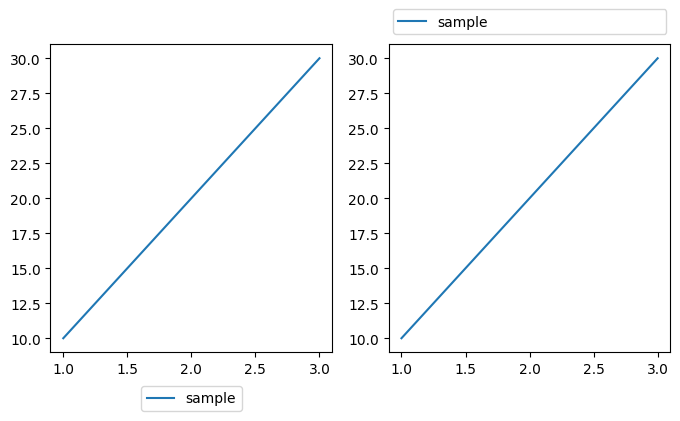

In [49]:
fig, axs = plt.subplots(1, 2, figsize=(8,4))
for ax in axs:
    ax.plot([1, 2, 3], [10, 20, 30], label='sample')

# Add first legend 0.5, -0.15, center
axs[0].legend(bbox_to_anchor=())

# Add second legend -0.01, 1.01, 1.02, 0.2. lower center. mode expand
axs[1].legend(bbox_to_anchor=(),)
# Box: x=0, y=1.02, width=1.02 (full axes width), height=0.2
# Legend expands to fill this box horizontally
plt.show()

## *Grid*

Gridlines help readers extract values from the plot.

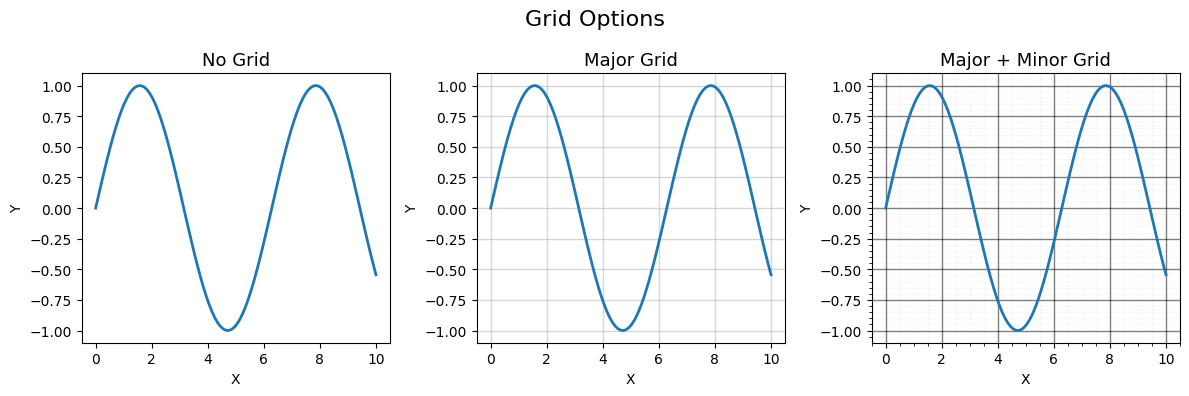

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

x = np.linspace(0, 10, 100)

# No grid
axes[0].plot(x, np.sin(x), linewidth=2)
axes[0].set_title('No Grid', fontsize=13)
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Major grid only
axes[1].plot(x, np.sin(x), linewidth=2)
axes[1].grid(True, which='major', alpha=0.5, linestyle='-', linewidth=1)
axes[1].set_title('Major Grid', fontsize=13)
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

# Major and minor grid
axes[2].plot(x, np.sin(x), linewidth=2)
axes[2].minorticks_on()
axes[2].grid(True, which='major', alpha=0.5, linestyle='-', linewidth=1, color='black')
axes[2].grid(True, which='minor', alpha=0.2, linestyle=':', linewidth=0.5, color='gray')
axes[2].set_title('Major + Minor Grid', fontsize=13)
axes[2].set_xlabel('X')
axes[2].set_ylabel('Y')

fig.suptitle('Grid Options', fontsize=16)
fig.tight_layout()
plt.show()

**Grid Main Parameters:**
- `which`: 'major', 'minor', or 'both'
- `alpha`: Transparency (0-1)
- `linestyle`: '-', '--', '-.', ':'
- `linewidth`: Line thickness
- `color`: Line color
- `axis`: 'both', 'x', or 'y'

## 3. Stem Plot - `stem()`

Plots vertical lines from baseline to each 𝑦 and puts a marker at each tip. Lets you control baseline position via bottom and basic style via linefmt, markerfmt, basefmt. For more control, you modify the objects it returns: markerline, stemlines, baseline.

> ```python
> markerline, stemlines, baseline = ax.stem(x, y, ...)
> ```

**Main Parameters:**
- `x` : X positions (default: `np.arange(len(y))`)
- `y` : Y values (required)
- `linefmt` : Line format string (default: `'C0-'`, controls stem line color and style)
- `markerfmt` : Marker format string (default: `'C0o'`, controls marker appearance)
- `basefmt` : Baseline format string (default: `'C3-'`, controls baseline appearance)
- `bottom` : Y position of baseline (default: `0`)
- `orientation`: 'vertical' or 'horizontal'
- `label` : Label for legend (default: `None`)

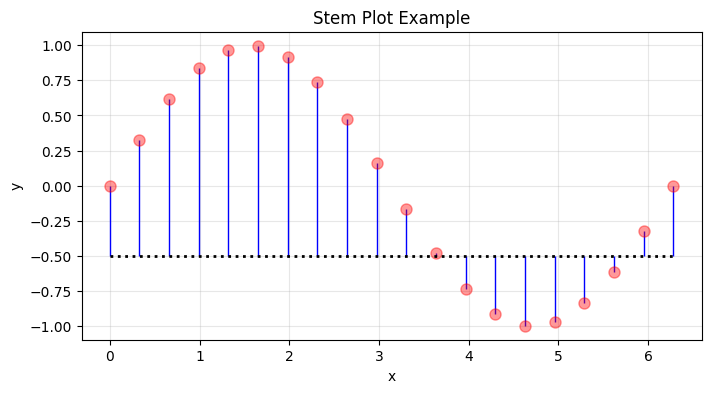

In [10]:
# create data
x = np.linspace(0, 2*np.pi, 20)
y = np.sin(x)

# create figure
fig, ax = plt.subplots(figsize=(8, 4))
markerline, stemlines, baseline = ax.stem(x, y,
                                          linefmt='blue', # stem color blue
                                          markerfmt='ro', # stem marker and color red square
                                          basefmt='k:', # baseline color and style
                                          bottom=-0.5) # starting points of stems
# more stem line properties
stemlines.set_linewidth(1)

# more marker properties
markerline.set_markersize(8)
markerline.set_alpha(0.4)

# more base line properties
baseline.set_linewidth(2)

ax.set_title('Stem Plot Example')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True, alpha=0.3)
plt.show()

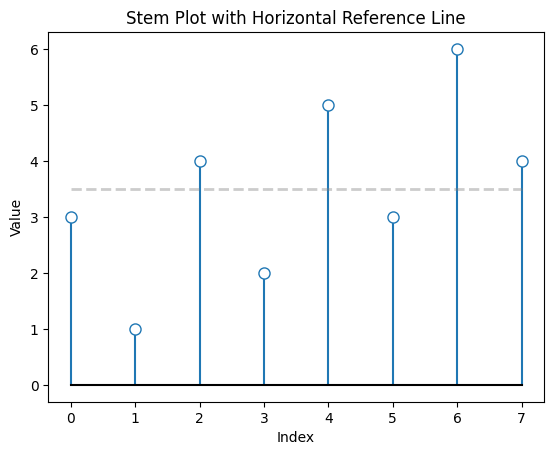

In [3]:
# Sample data
x = np.arange(0, 8)
y = np.array([3, 1, 4, 2, 5, 3, 6, 4])

fig, ax = plt.subplots()

# Create the stem plot
markerline, stemlines, baseline = ax.stem(x, y, basefmt='k-')

# Customize marker appearance (optional)
markerline.set(marker='o', markersize=8, markerfacecolor='white')

# Add a horizontal reference line at y = 3.5
ax.hlines(3.5, xmin=x.min(), xmax=x.max(), colors='gray', alpha= 0.4,  linestyles='--', linewidth=2)

# Basic labeling
ax.set_title("Stem Plot with Horizontal Reference Line")
ax.set_xlabel("Index")
ax.set_ylabel("Value")

plt.show()